<a href="https://colab.research.google.com/github/HimanshiChoubal/Machine_Learning_lab/blob/main/Assignment_4B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: Himanshi Choubal
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud


100%|██████████| 66.0M/66.0M [00:00<00:00, 831MB/s]

       Metric  K  Accuracy  Precision    Recall        F1       AUC
0   euclidean  1  0.912162   0.942857  0.880000  0.910345  0.912603
5   manhattan  1  0.915541   0.949640  0.880000  0.913495  0.916027
10  minkowski  1  0.912162   0.942857  0.880000  0.910345  0.912603
15     cosine  1  0.908784   0.942446  0.873333  0.906574  0.909269
6   manhattan  3  0.922297   0.977444  0.866667  0.918728  0.954110
9   manhattan  9  0.922297   0.992248  0.853333  0.917563  0.971849
7   manhattan  5  0.922297   0.992248  0.853333  0.917563  0.966324
8   manhattan  7  0.922297   0.992248  0.853333  0.917563  0.971096
16     cosine  3  0.912162   0.976923  0.846667  0.907143  0.947397
19     cosine  9  0.912162   0.984375  0.840000  0.906475  0.970411
2   euclidean  5  0.915541   0.992126  0.840000  0.909747  0.962900
3   euclidean  7  0.915541   0.992126  0.840000  0.909747  0.968014
13  minkowski  7  0.915541   0.992126  0.840000  0.909747  0.968014
18     cosine  7  0.912162   0.984375  0.840000 

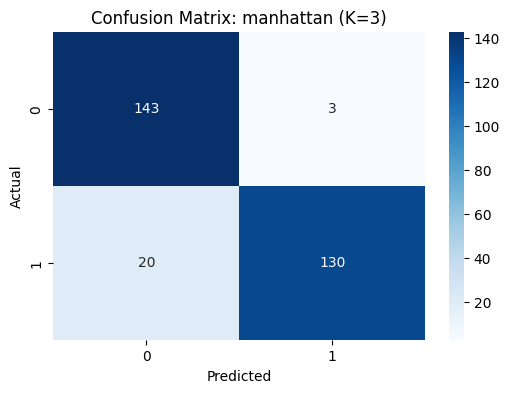

In [ ]:
# 1. Install necessary libraries
!pip install opendatasets pandas scikit-learn matplotlib seaborn -q

import opendatasets as od
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

# 2. Download the dataset directly from Kaggle
# You will be asked for your Kaggle Username and Key here.
dataset_url = 'https://www.kaggle.com/mlg-ulb/creditcardfraud'
od.download(dataset_url)

# 3. Load the data
# The path is usually 'folder_name/filename.csv'
df = pd.read_csv('creditcardfraud/creditcard.csv')

# 4. Balancing & Preprocessing
# Sampling because KNN is slow on huge datasets (O(n^2) complexity)
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0].sample(len(fraud), random_state=42)
balanced_df = pd.concat([fraud, normal])

X = balanced_df.drop('Class', axis=1)
y = balanced_df['Class']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# 5. Experiments: Distance Metrics & K-Values
metrics = ['euclidean', 'manhattan', 'minkowski', 'cosine']
k_values = [1, 3, 5, 7, 9]
results = []

for metric in metrics:
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
        knn.fit(X_train, y_train)

        y_pred = knn.predict(X_test)
        y_prob = knn.predict_proba(X_test)[:, 1]

        results.append({
            'Metric': metric, 'K': k,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred),
            'F1': f1_score(y_test, y_pred),
            'AUC': roc_auc_score(y_test, y_prob)
        })

# 6. Comparison Table
results_df = pd.DataFrame(results)
print(results_df.sort_values(by='Recall', ascending=False))

# 7. Best Model Confusion Matrix Visualization
best_params = results_df.loc[results_df['F1'].idxmax()]
print(f"\nBest Model based on F1-Score: {best_params['Metric']} with K={best_params['K']}")

best_knn = KNeighborsClassifier(n_neighbors=int(best_params['K']), metric=best_params['Metric'])
best_knn.fit(X_train, y_train)
y_pred_final = best_knn.predict(X_test)

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix: {best_params['Metric']} (K={best_params['K']})")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()